In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [2]:
df = pd.read_csv("Training_Dataset.csv")

print("Dataset shape:", df.shape)

Dataset shape: (11055, 31)


In [3]:
X = df.drop(columns=['Result'])
y = df['Result']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (11055, 30)
Target shape: (11055,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (8844, 30)
Testing set: (2211, 30)


In [5]:
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_baseline.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [6]:
y_pred_baseline = rf_baseline.predict(X_test)

accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
precision_baseline = precision_score(
    y_test, y_pred_baseline, pos_label=1
)
recall_baseline = recall_score(
    y_test, y_pred_baseline, pos_label=1
)
f1_baseline = f1_score(
    y_test, y_pred_baseline, pos_label=1
)

print("Baseline Random Forest")
print("----------------------")
print(f"Accuracy : {accuracy_baseline:.4f}")
print(f"Precision: {precision_baseline:.4f}")
print(f"Recall   : {recall_baseline:.4f}")
print(f"F1-score : {f1_baseline:.4f}")

Baseline Random Forest
----------------------
Accuracy : 0.9742
Precision: 0.9696
Recall   : 0.9846
F1-score : 0.9770


In [7]:
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold

rf_for_selection = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rfecv = RFECV(
    estimator=rf_for_selection,
    step=1,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

rfecv.fit(X_train, y_train)

print("Optimal number of features:", rfecv.n_features_)

Optimal number of features: 24


In [8]:
selected_features_rfecv = X.columns[rfecv.support_].tolist()

print("Selected features:")
print(selected_features_rfecv)

print("\nNumber of selected features:", len(selected_features_rfecv))

Selected features:
['having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Redirect', 'popUpWidnow', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report']

Number of selected features: 24


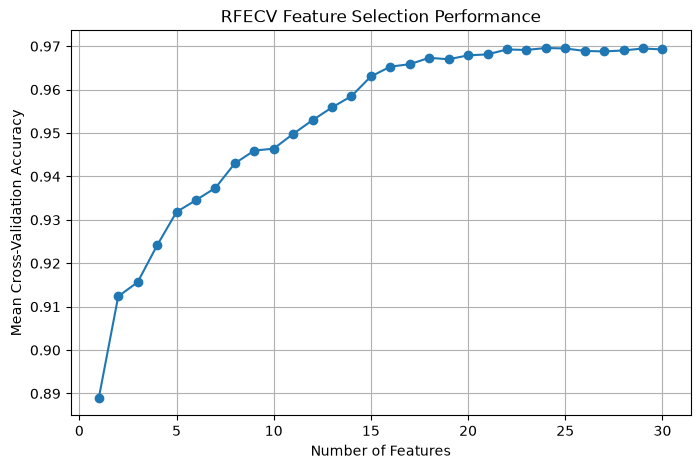

In [9]:
rfecv_results = pd.DataFrame({
    'Number of Features': rfecv.cv_results_['n_features'],
    'Mean CV Accuracy': rfecv.cv_results_['mean_test_score']
})

plt.figure(figsize=(8, 5))

plt.plot(
    rfecv_results['Number of Features'],
    rfecv_results['Mean CV Accuracy'],
    marker='o'
)

plt.xlabel('Number of Features')
plt.ylabel('Mean Cross-Validation Accuracy')
plt.title('RFECV Feature Selection Performance')
plt.grid()

plt.show()

In [10]:
X_train_rfecv = X_train[selected_features_rfecv]
X_test_rfecv = X_test[selected_features_rfecv]

print("Final training set:", X_train_rfecv.shape)
print("Final testing set:", X_test_rfecv.shape)

Final training set: (8844, 24)
Final testing set: (2211, 24)


In [11]:
rf_final = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_final.fit(X_train_rfecv, y_train)

y_pred_final = rf_final.predict(X_test_rfecv)

accuracy_final = accuracy_score(y_test, y_pred_final)
precision_final = precision_score(
    y_test, y_pred_final, pos_label=1
)
recall_final = recall_score(
    y_test, y_pred_final, pos_label=1
)
f1_final = f1_score(
    y_test, y_pred_final, pos_label=1
)

print("Final Random Forest - RFECV Selected Features")
print("-----------------------------------------------")
print(f"Number of Features: {len(selected_features_rfecv)}")
print(f"Accuracy : {accuracy_final:.4f}")
print(f"Precision: {precision_final:.4f}")
print(f"Recall   : {recall_final:.4f}")
print(f"F1-score : {f1_final:.4f}")

Final Random Forest - RFECV Selected Features
-----------------------------------------------
Number of Features: 24
Accuracy : 0.9747
Precision: 0.9711
Recall   : 0.9838
F1-score : 0.9774


Final Confusion Matrix:
[[ 944   36]
 [  20 1211]]


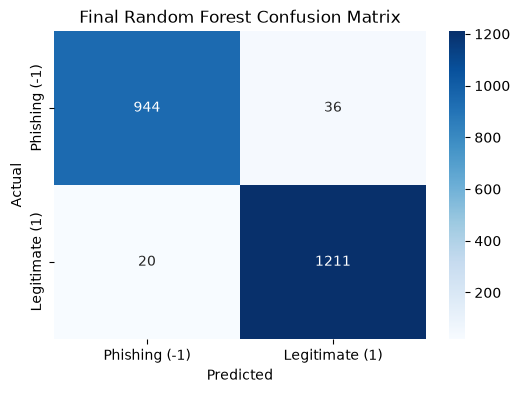

In [12]:
cm_final = confusion_matrix(y_test, y_pred_final)

print("Final Confusion Matrix:")
print(cm_final)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_final,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Phishing (-1)', 'Legitimate (1)'],
    yticklabels=['Phishing (-1)', 'Legitimate (1)']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Final Random Forest Confusion Matrix')

plt.show()

In [13]:
comparison = pd.DataFrame({
    'Baseline (30 Features)': [
        accuracy_baseline,
        precision_baseline,
        recall_baseline,
        f1_baseline
    ],
    'RFECV (24 Features)': [
        accuracy_final,
        precision_final,
        recall_final,
        f1_final
    ]
}, index=[
    'Accuracy',
    'Precision',
    'Recall',
    'F1-score'
])

display(comparison.round(4))

,Baseline (30 Features),RFECV (24 Features)
Accuracy,0.9742,0.9747
Precision,0.9696,0.9711
Recall,0.9846,0.9838
F1-score,0.9770,0.9774


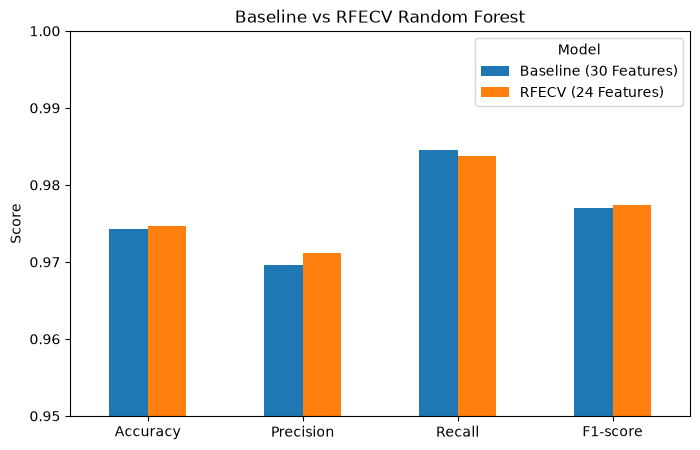

In [14]:
comparison.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Baseline vs RFECV Random Forest')
plt.ylabel('Score')
plt.ylim(0.95, 1.00)
plt.xticks(rotation=0)
plt.legend(title='Model')

plt.show()